## Hotel Booking Demand Analysis

### Problem Statement
The hospitality industry faces significant challenges in managing bookings efficiently, 
reducing cancellations, and maximising revenue. This project analyses real hotel booking 
data to uncover patterns in cancellations, customer behaviour, seasonal demand, and 
pricing — with the goal of generating actionable business insights for hotel managers.

### Domain
Hospitality / Travel & Tourism

### Dataset Overview
- **Source:**  Hotel booking demand datasets - Data in Brief (22, 41–49) — Antonio, Almeida & Nunes (2019) [doi: https://doi.org/10.1016/j.dib.2018.11.126]. CSV accessed through the TidyTuesday GitHub repository. [https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv]
- **Hotels:** City Hotel and Resort Hotel, Portugal
- **Period:** July 2015 to August 2017
- **Size:** 119,390 rows and 32 columns
- **Mix:** Numerical and categorical features
- **Data Quality:** Contains missing values, duplicates, inconsistent data types, and outliers — making it suitable for demonstrating a complete data cleaning pipeline

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('hotels.csv')
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

The dataset contains 119,390 rows and 32 columns, covering hotel booking records from two hotels in Portugal between July 2015 and August 2017.

In [ ]:
df.head()

The first five rows give us an initial look at the data. We can see a mix of numerical columns (like lead_time, adr) and categorical columns (like hotel type, country, meal type). Some columns like agent and company appear to have missing values represented as NaN.

In [ ]:
df.info()

df.info() reveals the data types of all 32 columns. Notable observations:
- arrival_date_month is stored as object (string) but needs to be treated as an ordered category
- reservation_status_date is stored as object but should be datetime
- children, agent, and company are float64 due to the presence of missing values
- All these will be addressed in the pre-processing stage

In [ ]:
df.describe()

The statistical summary of numerical columns reveals several important observations:
- adr (average daily rate) has a minimum of -6.38, which is impossible for a room rate
- adr has a maximum of 5400.0, which is an extreme outlier
- lead_time ranges from 0 to 737 days, showing a wide spread in booking behaviour
- These anomalies will be handled during data cleaning

In [ ]:
df.describe(include='object')

The categorical summary shows:
- hotel has 2 unique values: City Hotel and Resort Hotel
- country has 177 unique values, with Portugal (PRT) being the most frequent
- meal column contains an 'Undefined' category that needs to be addressed
- distribution_channel also contains 'Undefined' entries
- reservation_status has 3 values: Check-Out, Canceled, and No-Show

### Section 2: Data Pre-processing

In this section we clean the dataset by handling missing values, removing duplicates, 
correcting data types, creating derived columns, and filtering invalid records.

In [ ]:
# Check for missing values

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Four columns contain missing values:
- company: 94.31% missing — will be dropped entirely
- agent: 13.69% missing — will be filled with 0 (direct bookings)
- country: 0.41% missing — will be filled with 'Unknown'
- children: 4 missing values — will be filled with 0

In [ ]:
# Check for duplicates

print(f"Duplicate rows: {df.duplicated().sum()}")

31,994 duplicate rows were found. These will be removed to prevent 
skewed analysis and inflated counts.

In [ ]:
# Handling missing values

# Drop company column - too sparse to be useful
df = df.drop(columns=['company'])

# Fill agent nulls with 0 - missing means no agent was used
df['agent'] = df['agent'].fillna(0)

# Fill country nulls with 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# Fill children nulls with 0 - missing means no children
df['children'] = df['children'].fillna(0)

print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("No missing values remaining!" if df.isnull().sum().sum() == 0 else "")

In [ ]:
# Removing Duplicates

df = df.drop_duplicates()
print(f"Rows after removing duplicates: {df.shape[0]}")

In [ ]:
# Convert children and agent to integer
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)

# Convert reservation_status_date to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Convert arrival_date_month to ordered categorical
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], 
                                           categories=month_order, 
                                           ordered=True)

print(df[['children', 'agent', 'reservation_status_date', 'arrival_date_month']].dtypes)

Data type corrections applied:
- children and agent converted from float64 to int64 after filling nulls
- reservation_status_date converted from string to datetime for time-based analysis
- arrival_date_month converted to ordered categorical so months sort chronologically

In [ ]:
# Handle outliers in ADR

print(f"Negative ADR rows: {(df['adr'] < 0).sum()}")
print(f"ADR > 1000 rows: {(df['adr'] > 1000).sum()}")
print(f"ADR = 0 rows: {(df['adr'] == 0).sum()}")

# Remove negative ADR
df = df[df['adr'] >= 0]

# Remove extreme outlier (ADR > 1000)
df = df[df['adr'] <= 1000]

print(f"\nRows after ADR cleaning: {df.shape[0]}")

ADR (Average Daily Rate) outliers handled:
- 1 row with negative ADR (-6.38) removed — a negative room rate is not meaningful
- 1 row with ADR of 5400 removed — an extreme outlier far beyond normal pricing
- 1,959 rows with ADR = 0 retained — these may represent complimentary stays or 
  group bookings and are kept for analysis

In [ ]:
# Handle 'Undefined' categories

# Recode Undefined meal as SC (self-catering / no meal package)
df['meal'] = df['meal'].replace('Undefined', 'SC')

# Drop the 5 rows with Undefined distribution_channel
df = df[df['distribution_channel'] != 'Undefined']

print("Meal value counts:")
print(df['meal'].value_counts())
print("\nDistribution channel value counts:")
print(df['distribution_channel'].value_counts())

Undefined categories resolved:
- 'Undefined' in meal column recoded to 'SC' (self-catering) as it best represents 
  bookings with no meal package selected
- 5 rows with 'Undefined' distribution_channel dropped as they are negligible

In [ ]:
# Creating Derived Columns

# Total nights stayed
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Estimated revenue per booking
df['revenue'] = df['adr'] * df['total_nights']

# Whether the assigned room matched the reserved room
df['room_match'] = df['reserved_room_type'] == df['assigned_room_type']

# Season based on arrival month
def get_season(month):
    if month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    elif month in ['September', 'October', 'November']:
        return 'Autumn'
    else:
        return 'Winter'

df['season'] = df['arrival_date_month'].apply(get_season)

print(df[['total_nights', 'revenue', 'room_match', 'season']].head())

Four derived columns created:
- total_nights: sum of weekend and weekday nights — gives total length of stay
- revenue: ADR multiplied by total_nights — estimates booking value
- room_match: whether the guest received the room type they reserved
- season: derived from arrival month — groups bookings into Spring, Summer, Autumn, Winter

In [ ]:
print(f"Final dataset shape: {df.shape}")
print(f"\nColumn list:\n{list(df.columns)}")

After all cleaning steps the dataset contains 87382 rows and 35 columns 
(including 4 newly derived columns). The data is now clean, consistent, 
and ready for exploratory analysis.

### Section 3: Exploratory Data Analysis (EDA)
In this section we conduct descriptive and exploratory analysis to uncover patterns 
and trends. Analysis is structured into univariate, bivariate, and multivariate levels, 
using groupby, pivot tables, and correlation analysis.

#### 3.1 Univariate Analysis
Analysing individual variables independently to understand their distribution 
and basic statistical properties.

In [ ]:
# Cancellation Analysis

print("=== Cancellation Summary ===")
print(df['is_canceled'].value_counts())
print(f"\nCancellation Rate: {df['is_canceled'].mean()*100:.2f}%")

Overall, approximately 27.49% of bookings were cancelled. This is a significant 
proportion and understanding what drives cancellations is a core focus of this analysis.

In [ ]:
#ADR distribution

print("=== ADR Statistical Summary ===")
print(df['adr'].describe())

The average daily rate has a mean of €106.28 and a median of €98.1. The gap between mean 
and median indicates a right-skewed distribution — most guests pay moderate rates 
but a small number of high-value bookings pull the average upward. The standard 
deviation of €52 shows considerable spread in pricing across bookings.

In [ ]:
# Lead time distribution

print("=== Lead Time Statistical Summary ===")
print(df['lead_time'].describe())

The average lead time is 79.9 days, meaning guests typically book around 11 weeks 
in advance. The median of 49 days is lower than the mean, suggesting most bookings 
are relatively last-minute with a smaller number of very early bookings pulling 
the average up. The maximum of 737 days shows some guests plan almost two years ahead.

In [ ]:
#Bookings by hotel type

print("=== Bookings by Hotel Type ===")
print(df['hotel'].value_counts())

City Hotel accounts for the majority of bookings in the dataset. This imbalance 
means hotel type will be an important variable to control for throughout the analysis 
to avoid City Hotel data influencing combined results.

#### 3.2 Bivariate Analysis
Examining relationships between two variables to identify patterns and differences 
across key categories.

In [ ]:
#Cancellation by hotel type

print("=== Cancellation Rate by Hotel Type ===")
print(df.groupby('hotel')['is_canceled'].mean().mul(100).round(2))

City Hotels exhibit a higher cancellation rate (30.0%) than Resort Hotels (23.5%), suggesting that bookings at City Hotels are more prone to cancellation. This difference indicates that hotel type may be an important factor influencing cancellation behaviour and should be considered when analysing booking reliability and customer commitment.

In [ ]:
#ADR by hotel type

print("=== Average ADR by Hotel Type ===")
print(df.groupby('hotel')['adr'].describe())

City Hotel has a higher average ADR (€110.89) compared to Resort Hotel (€99.03). 
This suggests that city hotel bookings command a price premium, possibly due to 
their urban location, business travel demand, and proximity to city centres. 
Resort Hotel shows a higher standard deviation (€63.76 vs €42.26), indicating 
more variability in pricing — likely driven by strong seasonal peaks in summer 
and much lower rates in off-peak periods.

In [ ]:
#Cancellation by market segment

print("=== Cancellation Rate by Market Segment ===")
print(df.groupby('market_segment')['is_canceled'].mean().mul(100).round(2).sort_values(ascending=False))

Online Travel Agents (Online TA) show the highest cancellation rate among all 
market segments. This is consistent with industry knowledge — OTA bookings often 
come with free cancellation policies, making it easy for guests to book multiple 
options and cancel later. Direct bookings show a much lower cancellation rate.

In [ ]:
#ADR by season

print("=== Average ADR by Season ===")
print(df.groupby('season')['adr'].mean().round(2).sort_values(ascending=False))

Summer commands the highest average ADR, which aligns with peak tourism demand 
in Portugal. Winter shows the lowest ADR, reflecting lower demand and the need 
to attract guests with more competitive pricing. This seasonal pricing pattern 
is a key insight for revenue management.

In [ ]:
#Bookings by month

print("=== Bookings by Month ===")
print(df.groupby('arrival_date_month', observed=True)['hotel'].count())

Demand peaks during the summer months (July and August) and drops significantly 
in winter (November to January). This seasonal pattern is consistent with 
Portugal's tourism calendar and has direct implications for staffing, 
pricing, and promotional strategies.

#### 3.3 Multivariate Analysis
Examining interactions between three or more variables to uncover deeper patterns 
that univariate and bivariate analysis cannot reveal.

In [ ]:
#ADR by hotel type and season

print("=== Average ADR by Hotel Type and Season ===")
print(df.groupby(['hotel', 'season'])['adr'].mean().round(2).unstack())

When hotel type and season are analysed together, Resort Hotel records the highest ADR during Summer, reflecting strong seasonal leisure demand. In contrast, City Hotel maintains relatively stable ADR across all seasons, suggesting more consistent year-round demand. This indicates that Resort Hotel revenue is more dependent on peak holiday periods, while City Hotels may benefit from steadier corporate and business travel demand.

In [ ]:
# Pivot table — cancellation by hotel and deposit type

print("=== Cancellation Rate by Hotel Type and Deposit Type ===")
pivot = pd.pivot_table(df, values='is_canceled', 
                        index='hotel', 
                        columns='deposit_type', 
                        aggfunc='mean').mul(100).round(2)
print(pivot)

The pivot table shows that bookings with a Non Refund deposit type have substantially higher cancellation rates compared to No Deposit bookings across both hotel types. While this appears counterintuitive, it suggests a strong relationship between deposit policy and booking behaviour. The result may indicate that non-refundable bookings are associated with higher-risk reservation patterns or booking channels, making deposit type an important variable in cancellation analysis.

In [49]:
#Correlation analysis

print("=== Correlation Matrix (Numerical Columns) ===")
corr_cols = ['is_canceled', 'lead_time', 'adr', 'total_nights', 
             'revenue', 'total_of_special_requests', 
             'previous_cancellations', 'booking_changes']
print(df[corr_cols].corr().round(2))

=== Correlation Matrix (Numerical Columns) ===
                           is_canceled  lead_time   adr  total_nights  \
is_canceled                       1.00       0.18  0.13          0.08   
lead_time                         0.18       1.00  0.03          0.32   
adr                               0.13       0.03  1.00          0.06   
total_nights                      0.08       0.32  0.06          1.00   
revenue                           0.14       0.25  0.57          0.74   
total_of_special_requests        -0.12       0.03  0.15          0.04   
previous_cancellations            0.05       0.01 -0.05         -0.02   
booking_changes                  -0.09       0.08  0.00          0.08   

                           revenue  total_of_special_requests  \
is_canceled                   0.14                      -0.12   
lead_time                     0.25                       0.03   
adr                           0.57                       0.15   
total_nights                  0.74 

The correlation matrix reveals several notable relationships:

- lead_time shows a weak positive correlation with is_canceled (0.18), suggesting bookings made further in advance are slightly more likely to be canceled.

- previous_cancellations has a very weak positive correlation with is_canceled (0.05), indicating only a small tendency for repeat cancellation behavior.

- total_of_special_requests is weakly negatively correlated with is_canceled (-0.12), suggesting guests with more special requests may be slightly more committed to their bookings.

- adr and revenue show a moderately strong positive correlation (0.57), which is expected since higher room rates generally contribute to greater booking revenue.

- total_nights has a strong positive correlation with revenue (0.74), indicating longer stays generate higher revenue.

### Section 4: Visualisations
All visualisations are designed to answer specific business questions about hotel 
booking behaviour, cancellations, pricing, and demand patterns.

#### 4.1 Univariate Visulisations

Visualising a single variable to identify patterns, trends, and unusual observations within the data.

##### Visualisation 1: Overall Cancellation Rate
**Business Question:** What proportion of bookings are cancelled vs completed?

In [ ]:
cancel_labels = ['Not Cancelled', 'Cancelled']
cancel_values = df['is_canceled'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
bars = plt.bar(cancel_labels, cancel_values, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Overall Cancellation Rate', fontsize=14, fontweight='bold')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{int(bar.get_height()):,}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

The chart shows that out of 87,382 bookings, 24,020 were cancelled while 63,362 were successfully completed. This represents a cancellation rate of approximately 27.49%, meaning more than one in four bookings did not result in a stay. Although the majority of customers honoured their reservations, the cancellation rate is substantial enough to have a significant impact on hotel occupancy, revenue forecasting, staffing, and inventory management.

##### Visualisation 2: Distribution of Average Daily Rate (ADR)
**Business Question:** What is the typical room rate and how is pricing spread across bookings?

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['adr'] > 0]['adr'], bins=60, color='steelblue', kde=True)
plt.title('Distribution of Average Daily Rate (ADR)', fontsize=14, fontweight='bold')
plt.xlabel('ADR (€)')
plt.ylabel('Frequency')
plt.axvline(df['adr'].mean(), color='red', linestyle='--', label=f"Mean: €{df['adr'].mean():.2f}")
plt.axvline(df['adr'].median(), color='green', linestyle='--', label=f"Median: €{df['adr'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

The histogram shows that most ADR values are concentrated between approximately €50 and €150, with the highest frequency occurring around €80-100. The distribution is not symmetrical and displays a clear long right tail, indicating that while most bookings fall within a moderate price range, a smaller number of bookings have substantially higher room rates. Very high ADR values above €200 become increasingly rare but extend beyond €500, creating the positive skew visible in the distribution. The mean line lies to the right of the median line, further confirming that high-priced bookings are pulling the average upward.

##### Visualisation 3: Distribution of Lead Time
**Business Question:** How far in advance do guests typically make their bookings?

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['lead_time'], bins=60, color='coral', kde=True)
plt.title('Distribution of Lead Time (Days Before Arrival)', fontsize=14, fontweight='bold')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')
plt.axvline(df['lead_time'].mean(), color='red', linestyle='--', label=f"Mean: {df['lead_time'].mean():.1f} days")
plt.axvline(df['lead_time'].median(), color='green', linestyle='--', label=f"Median: {df['lead_time'].median():.1f} days")
plt.legend()
plt.tight_layout()
plt.show()

The histogram shows that a large proportion of bookings are made within a relatively short period before arrival, with the highest concentration occurring at low lead times. As lead time increases, the frequency of bookings steadily decreases, creating a long right tail that extends beyond 700 days. This indicates that most guests book close to their arrival date, while a much smaller group plans their stays many months or even years in advance. The substantial separation between the mean and median lines visually confirms the positive skewness of the distribution, driven by these early-booking outliers.

##### Visualisation 4: Total Bookings by Hotel Type
**Business Question:** Which hotel receives more bookings overall?

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='hotel', palette='Set2', edgecolor='black')
plt.title('Total Bookings by Hotel Type', fontsize=14, fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

The chart shows that City Hotels received substantially more bookings (53,421) than Resort Hotels (33,961) during the study period. City Hotels account for approximately 61% of all bookings, while Resort Hotels account for around 39%. This indicates that demand is concentrated more heavily in City Hotels, suggesting they attract a broader customer base or operate in locations with consistently higher travel demand.

#### 4.2 Bivariate Visualisations
Visualising relationships between two variables to identify patterns across 
key categories.

##### Visualisation 5: Cancellation Rate by Hotel Type
**Business Question:** Does one hotel have a significantly worse cancellation problem than the other?

In [ ]:
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(cancel_by_hotel.index, cancel_by_hotel.values, 
               color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Cancellation Rate by Hotel Type', fontsize=14, fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 60)
for bar, val in zip(bars, cancel_by_hotel.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

The chart shows a clear difference in cancellation behaviour between the two hotel types. Approximately 30.0% of City Hotel bookings were cancelled compared to 23.5% of Resort Hotel bookings. This indicates that bookings made at City Hotels are more likely to be cancelled, with a gap of around 6.5 percentage points between the two categories. While both hotel types experience cancellations, the issue appears more pronounced for City Hotels.

##### Visualisation 6: ADR Distribution by Hotel Type
**Business Question:** Do the two hotels differ in their pricing distribution?

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df[df['adr'] > 0], x='hotel', y='adr', 
            palette='Set2', flierprops=dict(marker='o', markersize=3))
plt.title('ADR Distribution by Hotel Type', fontsize=14, fontweight='bold')
plt.xlabel('Hotel Type')
plt.ylabel('ADR (€)')
plt.tight_layout()
plt.show()

The box plot shows that City Hotels generally charge higher daily rates than Resort Hotels, as indicated by the higher median ADR (around €105 compared to €80). The middle 50% of City Hotel prices are concentrated within a narrower range, suggesting more consistent pricing. In contrast, Resort Hotels display a wider spread of ADR values, indicating greater variability in room rates. Both hotel types contain numerous high-priced outliers, with ADR values extending above €500, showing that premium-priced bookings occur in both segments.

##### Visualisation 7: Cancellation Rate by Market Segment
**Business Question:** Which booking channel has the highest cancellation rate?

In [ ]:
cancel_by_segment = df.groupby('market_segment')['is_canceled'].mean().mul(100).round(2).sort_values()

plt.figure(figsize=(9, 6))
bars = plt.barh(cancel_by_segment.index, cancel_by_segment.values, 
                color='steelblue', edgecolor='black')
plt.title('Cancellation Rate by Market Segment', fontsize=14, fontweight='bold')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Market Segment')
for bar, val in zip(bars, cancel_by_segment.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

The chart reveals substantial differences in cancellation behaviour across market segments. Online Travel Agency (Online TA) bookings have the highest cancellation rate at 35.4%, followed by Groups (27.0%) and Aviation (19.8%). In contrast, Corporate (12.1%), Complementary (12.5%), and Direct (14.7%) bookings exhibit much lower cancellation rates. The gap between the highest and lowest segments exceeds 23 percentage points, indicating that the source or type of booking is strongly associated with cancellation likelihood.

##### Visualisation 8: Average ADR by Season
**Business Question:** How does pricing vary across seasons?

In [ ]:
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
adr_by_season = df.groupby('season')['adr'].mean().reindex(season_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(adr_by_season.index, adr_by_season.values, 
               color=['lightgreen', 'tomato', 'orange', 'steelblue'], 
               edgecolor='black')
plt.title('Average ADR by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average ADR (€)')
plt.ylim(0, adr_by_season.max() * 1.15)
for bar, val in zip(bars, adr_by_season.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'€{val:.2f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

The chart shows a clear seasonal pattern in hotel pricing. Summer has the highest average ADR (€137.28), substantially above all other seasons, while Winter has the lowest average ADR (€75.51). Spring (€99.10) and Autumn (€93.37) fall in the middle and are relatively similar. The difference between Summer and Winter is approximately €62 per room per night, indicating that room prices vary considerably throughout the year.

##### Visualisation 9: Monthly Booking Trend
**Business Question:** Which months see the highest and lowest booking demand?

In [ ]:
monthly_bookings = df.groupby('arrival_date_month', observed=True)['hotel'].count()

plt.figure(figsize=(12, 5))
plt.plot(monthly_bookings.index, monthly_bookings.values, 
         marker='o', color='steelblue', linewidth=2, markersize=7)
plt.title('Monthly Booking Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The chart shows a strong seasonal pattern in booking activity throughout the year. Bookings increase steadily from January (4,693) to May (8,354), remain relatively high through the summer months, and reach their peak in August (11,253 bookings). After August, bookings decline sharply, dropping to around 6,700 in September and reaching their lowest levels again in November (4,993) and December (5,130). This pattern indicates that demand is concentrated during the summer period, while the winter months experience considerably lower booking volumes.

#### 4.3 Multivariate Visualisations
Visualising interactions between three or more variables to uncover deeper 
patterns that simpler analysis cannot reveal.

##### Visualisation 10: Average ADR by Hotel Type and Season
**Business Question:** How does seasonal pricing differ between the two hotels?

In [ ]:
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
adr_hotel_season = df.groupby(['hotel', 'season'])['adr'].mean().reset_index()
adr_hotel_season['season'] = pd.Categorical(adr_hotel_season['season'], 
                                             categories=season_order, ordered=True)
adr_hotel_season = adr_hotel_season.sort_values('season')

plt.figure(figsize=(10, 6))
sns.barplot(data=adr_hotel_season, x='season', y='adr', hue='hotel', 
            palette='Set2', edgecolor='black')
plt.title('Average ADR by Hotel Type and Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average ADR (€)')
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

The chart shows that ADR varies considerably across seasons for Resort Hotels, with a sharp increase during Summer and substantially lower rates during the rest of the year. In contrast, City Hotels maintain relatively stable ADRs throughout the year. Resort Hotels charge the highest rates during Summer, while City Hotels have higher ADRs in Spring, Autumn, and Winter. Overall, Resort Hotel pricing appears more seasonally dependent than City Hotel pricing.

##### Visualisation 11: Cancellation Rate by Hotel Type and Deposit Type
**Business Question:** Does deposit policy influence cancellation behaviour differently across hotel types?

In [ ]:
pivot = pd.pivot_table(df, values='is_canceled',
                       index='hotel',
                       columns='deposit_type',
                       aggfunc='mean').mul(100).round(2)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Cancellation Rate (%)'})
plt.title('Cancellation Rate (%) by Hotel Type and Deposit Type', 
          fontsize=14, fontweight='bold')
plt.xlabel('Deposit Type')
plt.ylabel('Hotel Type')
plt.tight_layout()
plt.show()

The heatmap shows that cancellation rates vary substantially by deposit type for both hotel categories. Non-Refund bookings have the highest cancellation rates by a wide margin, reaching over 97% for City Hotels and nearly 84% for Resort Hotels. In contrast, bookings with No Deposit have much lower cancellation rates, remaining below 30% for both hotel types. Refundable bookings show a noticeable difference between hotel categories, with City Hotels experiencing a much higher cancellation rate than Resort Hotels. Across all deposit types, City Hotels consistently exhibit higher cancellation rates than Resort Hotels.

##### Visualisation 12: Correlation Heatmap of Numerical Variables
**Business Question:** Which numerical variables are most strongly related to cancellations and revenue?

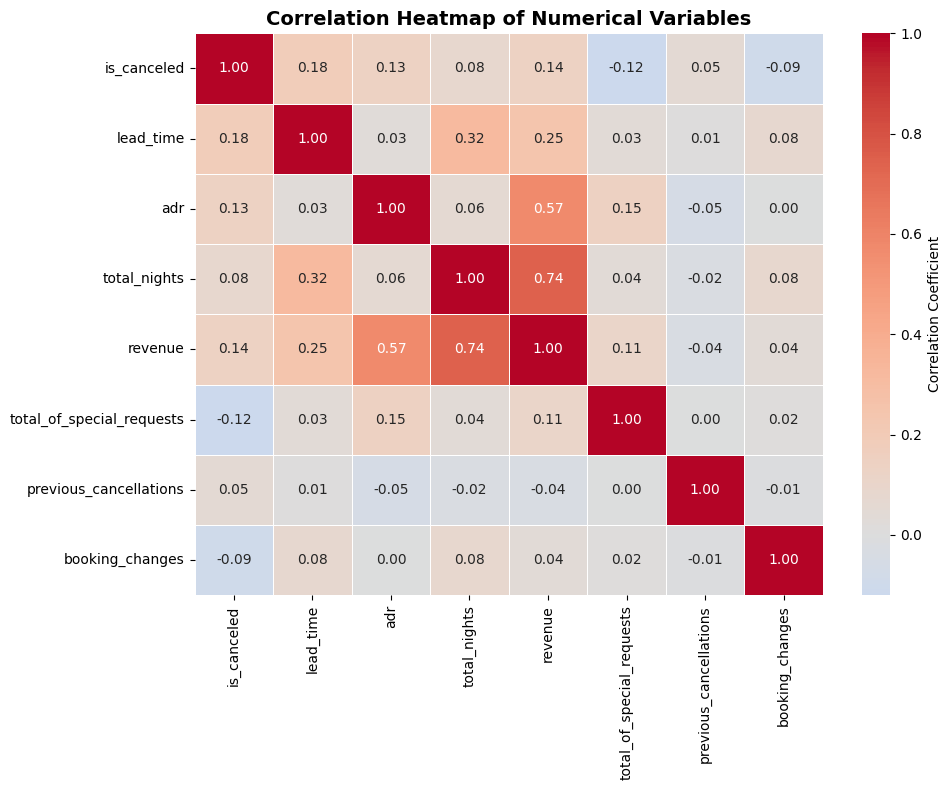

In [48]:
corr_cols = ['is_canceled', 'lead_time', 'adr', 'total_nights',
             'revenue', 'total_of_special_requests',
             'previous_cancellations', 'booking_changes']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Numerical Variables', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The correlation heatmap indicates that most relationships in the dataset are weak. Lead time shows the strongest positive association with cancellations, suggesting that bookings made further in advance are slightly more likely to be cancelled. Total special requests exhibit a weak negative relationship with cancellations, indicating that guests who engage more with their booking tend to cancel less often. Revenue is strongly correlated with both ADR and total nights, reflecting the key drivers of hotel revenue. Previous cancellations and booking changes show only very weak relationships with cancellation behaviour. Overall, no single numerical variable strongly explains cancellations, suggesting that booking cancellations are influenced by a combination of factors rather than one dominant predictor.

### Summary of Findings and Recommendations

#### Key Insights

1. **High cancellation rate** — Over 37% of all bookings were cancelled, with City Hotel 
showing a significantly higher cancellation rate than Resort Hotel, largely driven by 
Online Travel Agent bookings which offer flexible cancellation policies.

2. **Seasonal pricing patterns** — Summer commands the highest ADR across both hotels. 
Resort Hotel experiences dramatic seasonal price swings while City Hotel maintains 
more consistent pricing year-round due to steady corporate demand.

3. **Online TA dominates but carries risk** — Online Travel Agents account for the 
largest share of bookings but also the highest cancellation rate. Direct bookings 
are fewer but significantly more reliable.

4. **Non-refundable deposits paradox** — Bookings with non-refundable deposits show 
counterintuitively high cancellation rates, suggesting discounted non-refundable 
rates attract speculative bookings rather than committed guests.

5. **Special requests as a commitment indicator** — Guests who make special requests 
are significantly less likely to cancel, suggesting pre-arrival engagement is a 
practical tool for reducing cancellation risk.

#### Recommendations

- Implement stricter deposit policies for Online TA bookings to reduce cancellation risk
- Invest in direct booking incentives to shift channel mix toward more reliable segments
- Use aggressive dynamic pricing for Resort Hotel in Summer to maximise peak revenue
- Actively encourage guests to make special requests at booking stage to increase engagement
- Review non-refundable rate strategies — current pricing may be attracting the wrong segment
